# Different ways to split dataset into Train and Test

Asuuming all the variables used in main analysisis present here

Spliting the dataset in Train : Test in 80:20 ratio chronologically

In [ ]:
# Assuming your dataset is named 'DATA'
n <- nrow(DATA)  # Total number of rows
split_index <- round(0.8 * n)  # 80% split point

# Directly split without shuffling
train_data <- DATA[1:split_index, ]  # First 80% for training
test_data <- DATA[(split_index + 1):n, ]  # Remaining 20% for testing

# Display results
print(train_data)
cat("Train set dimensions:", dim(train_data), "\n")
cat("Test set dimensions:", dim(test_data), "\n")

      y x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10
1  19.2   0 3.85  66  9.35 5.65 2.40 3.25 0.33  19 0.065
2  18.3   0 3.73  79 11.15 6.95 3.15 3.80 0.36  21 0.076
3  17.1   0 3.88  73  9.40 5.75 2.10 3.65 0.40  18 0.073
4  17.3   0 3.86  99 12.85 7.70 3.90 3.80 0.35  22 0.076
5  16.8   0 3.98  75  8.55 5.05 2.05 3.00 0.49  12 0.060
6  16.5   0 3.85  61 10.30 6.20 2.50 3.70 0.38  20 0.074
7  15.8   0 3.93  66  4.90 2.75 1.20 1.55 0.29  11 0.031
8  15.2   0 3.66  86  6.40 4.00 1.50 2.50 0.27  19 0.050
9  15.2   0 3.91  78  5.80 3.30 1.40 1.90 0.40   9 0.038
10 14.0   0 3.47 178  3.60 2.25 0.75 1.50 0.37   8 0.030
11 14.0   0 3.91  81  3.90 2.15 1.00 1.15 0.32   7 0.023
12 13.8   0 3.75 108  5.80 3.20 1.60 1.60 0.38   8 0.032
13 13.6   0 3.90  92  5.40 2.85 1.55 1.30 0.44   6 0.026
14 12.8   0 3.92  96  5.00 2.70 1.40 1.30 0.35   7 0.026
15 18.5   1 3.87  89  9.15 5.60 1.95 3.65 0.46  16 0.073
16 17.3   1 3.97  59 10.25 6.10 2.40 3.70 0.40  19 0.074
17 16.3   1 3.76  22  8.20 5.00

Spliting the datse in Train : Test with randomness

In [ ]:
# Set seed for reproducibility
set.seed(40500)

# Assuming your dataset is named 'DATA'
n <- nrow(DATA)  # Total number of rows

# Shuffle rows while keeping columns in place
shuffled_indices <- sample(1:n)
print(shuffled_indices)
shuffled_data <- DATA[shuffled_indices, ]  # Shuffle only rows, columns remain intact
print(shuffled_data)
# Generating random indices for training (80%)
#train_indices <- sample(1:n, size = round(0.8 * n))
train_data <- shuffled_data[1:split_index, ]
test_data <- shuffled_data[(split_index + 1):n, ]
# Split dataset
#train_data <- shuffled_data[train_indices, ]  # Training set
#test_data <- shuffled_data[-train_indices, ]  # Test set

# Display results
print(train_data)
cat("Train set dimensions:", dim(train_data), "\n")
cat("Test set dimensions:", dim(test_data), "\n")

 [1]  6 15 24 30  5 26 19 28  2 18  8 21  1 20  3  7 25 17 27 12 11 22  9 16 23
[26] 32 13  4 14 10 31 29
      y x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10
6  16.5   0 3.85  61 10.30 6.20 2.50 3.70 0.38  20 0.074
15 18.5   1 3.87  89  9.15 5.60 1.95 3.65 0.46  16 0.073
24 15.3   1 3.77 144  5.60 3.35 1.10 2.25 0.36  12 0.045
30 13.8   1 3.90  67  7.40 4.40 1.60 2.80 0.45  13 0.056
5  16.8   0 3.98  75  8.55 5.05 2.05 3.00 0.49  12 0.060
26 14.3   1 3.76 100  5.55 3.25 1.15 2.10 0.34  12 0.042
19 16.0   1 3.98  58 10.15 6.00 2.60 3.40 0.38  18 0.068
28 14.2   1 3.60 301  4.25 2.40 1.25 1.15 0.42   6 0.023
2  18.3   0 3.73  79 11.15 6.95 3.15 3.80 0.36  21 0.076
18 16.3   1 3.76  77  8.35 5.05 1.90 3.15 0.37  17 0.063
8  15.2   0 3.66  86  6.40 4.00 1.50 2.50 0.27  19 0.050
21 15.7   1 3.75 120  8.80 5.50 1.85 3.65 0.39  19 0.073
1  19.2   0 3.85  66  9.35 5.65 2.40 3.25 0.33  19 0.065
20 16.0   1 3.88  85  6.85 4.10 1.50 2.60 0.33  16 0.052
3  17.1   0 3.88  73  9.40 5.75 2.10 3.

L2 regularization


In [ ]:
x <- as.matrix(train_data_removedOutliers[, -which(names(train_data_removedOutliers) == "y")])  # predictors
y <- train_data_removedOutliers$y

In [ ]:
cv_ridge <- cv.glmnet(x, y, alpha = 0)
best_lambda <- cv_ridge$lambda.min

Warning message:
“Option grouped=FALSE enforced in cv.glmnet, since < 3 observations per fold”


In [ ]:
final_ridge_model <- glmnet(x, y, alpha = 0, lambda = best_lambda)


In [ ]:
vif_values_withoutOutliers <- vif(final_ridge_model)  # Use OLS to check VIF
print(vif_values_withoutOutliers)

ERROR: Error in UseMethod("vcov"): no applicable method for 'vcov' applied to an object of class "c('elnet', 'glmnet')"


In [ ]:
coef(final_ridge_model)

11 x 1 sparse Matrix of class "dgCMatrix"
                      s0
(Intercept)  8.325097631
x_1         -0.193381596
x_2          0.894404538
x_3         -0.005169279
x_4          0.102063650
x_5          0.166529134
x_6          0.386146672
x_7          0.248613771
x_8          1.085880444
x_9          0.031538475
x_10        12.422573162

In [ ]:
test_data_variables <- test_data[, colnames(test_data) != "y"]
print(test_data_variables)

   x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10
4    0 3.86  99 12.85 7.70 3.90 3.80 0.35  22 0.076
6    0 3.85  61 10.30 6.20 2.50 3.70 0.38  20 0.074
7    0 3.93  66  4.90 2.75 1.20 1.55 0.29  11 0.031
18   1 3.76  77  8.35 5.05 1.90 3.15 0.37  17 0.063
21   1 3.75 120  8.80 5.50 1.85 3.65 0.39  19 0.073
29   1 3.76 104  8.70 5.10 2.25 2.85 0.34  17 0.057


In [ ]:
test_data_df <- as.data.frame(test_data)

In [ ]:
x_test <- as.matrix(test_data[, setdiff(names(test_data), "y")])

In [ ]:
# For train/test split
test_data_precited$predicted_afterL2 <- predict(final_ridge_model, s = best_lambda, newx = x_test)

In [ ]:
actuals <- test_data$y
predicted_L2 <- test_data_precited$predicted_afterL2

#rss2<- sum((actuals - predicted_robust2)^2)
rmse_L2 <- sqrt(mean((actuals - predicted_L2)^2))
r_squared_L2 <- cor(actuals, predicted_L2)^2

Robust ridged Regression

In [ ]:
# Get robust model summary before shrinkage
summary_rlm <- summary(robust_model)

# Extract estimates and standard errors (before shrinkage)
orig_estimates <- coef(summary_rlm)[, "Value"]
std_errors <- coef(summary_rlm)[, "Std. Error"]

# Apply ridge shrinkage manually
lambda_opt <- optimal_lambda
shrunken_estimates <- orig_estimates[-1] / (1 + lambda_opt)  # excluding intercept
intercept <- orig_estimates[1]

# Adjust standard errors (approximation, assuming same SE structure)
shrunken_se <- std_errors[-1] / (1 + lambda_opt)
intercept_se <- std_errors[1]

# Calculate t-values
t_values <- shrunken_estimates / shrunken_se
t_values_intercept <- intercept / intercept_se

# Approximate p-values (2-sided) using t-distribution
df <- nrow(train_data) - length(shrunken_estimates) - 1
p_values <- 2 * pt(-abs(t_values), df = df)
p_values_intercept <- 2 * pt(-abs(t_values_intercept), df = df)

# Combine into a summary table
coef_table <- data.frame(
  Coefficient = c("(Intercept)", names(shrunken_estimates)),
  Estimate = round(c(intercept, shrunken_estimates), 5),
  `Std. Error` = round(c(intercept_se, shrunken_se), 5),
  `t value` = round(c(t_values_intercept, t_values), 3),
  `Pr(>|t|)` = signif(c(p_values_intercept, p_values), 4)
)

cat("\n=== Approximate Significance of Robust Ridge Coefficients (Lambda =", lambda_opt, ") ===\n")
print(coef_table, row.names = FALSE)


=== Robust Ridge Coefficients and Approximate Significance (Lambda = 1.2 ) ===
 Coefficient Estimate Std..Error t.value  Pr...t..
 (Intercept) 15.20767    0.26245  57.946 5.625e-21
 x_scaledx_1 -0.21387    0.17835  -1.199 2.469e-01
 x_scaledx_2  0.36848    0.28111   1.311 2.074e-01
 x_scaledx_3  0.38722    0.27158   1.426 1.720e-01
 x_scaledx_4 -0.46001    2.77621  -0.166 8.704e-01
 x_scaledx_5  1.75031    2.50616   0.698 4.944e-01
 x_scaledx_6 -0.37127    0.61540  -0.603 5.543e-01
 x_scaledx_8 -0.53983    0.35759  -1.510 1.495e-01
 x_scaledx_9 -0.30447    0.73349  -0.415 6.833e-01


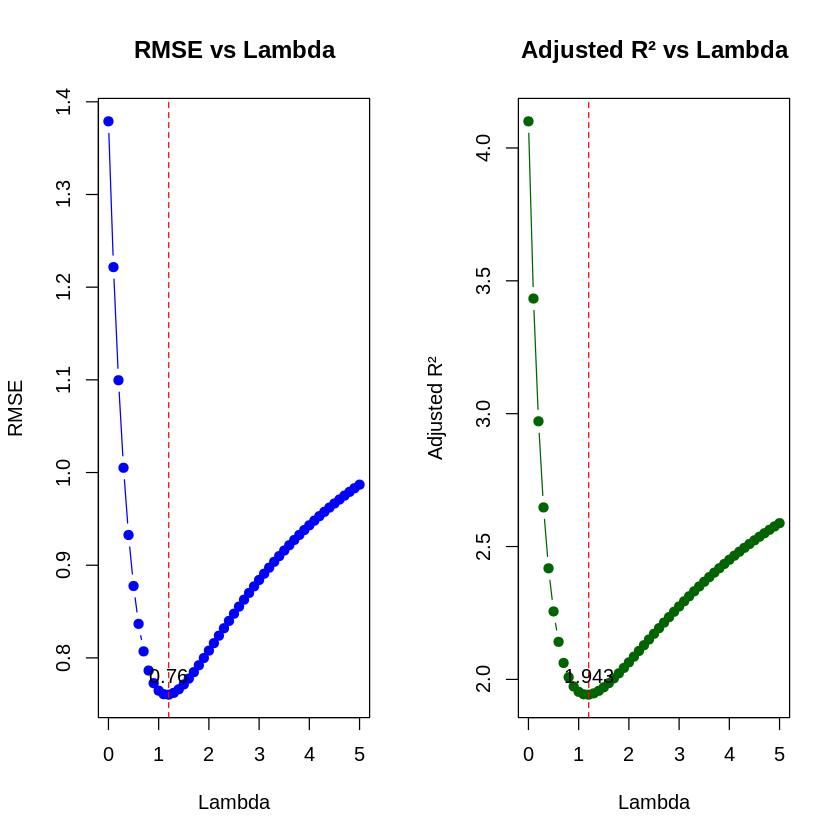

In [ ]:
library(MASS)

# Step 1: Robust regression on scaled training data
x <- as.matrix(train_data[, 2:11])
x <- x[, !colnames(x) %in% c("x_7", "x_10")]
y <- train_data$y
x_scaled <- scale(x)
robust_model <- rlm(y ~ x_scaled, psi = psi.huber)

# Step 2: Lambda grid
lambda_values <- seq(0, 5, by = 0.1)
rmse_values <- numeric(length(lambda_values))
adj_r2_values <- numeric(length(lambda_values))

# Step 3: Scale test data using training scale
x_test <- as.matrix(test_data[, colnames(x)])
x_test_scaled <- scale(x_test,
                       center = attr(x_scaled, "scaled:center"),
                       scale = attr(x_scaled, "scaled:scale"))

# Step 4: Loop over lambdas
for (i in seq_along(lambda_values)) {
  lambda <- lambda_values[i]
  beta_ridge_robust <- coef(robust_model)[-1] / (1 + lambda)
  intercept <- coef(robust_model)[1]

  y_pred <- intercept + x_test_scaled %*% beta_ridge_robust
  residuals <- test_data$y - y_pred
  rmse_values[i] <- sqrt(mean(residuals^2))

  ss_res <- sum(residuals^2)
  ss_tot <- sum((test_data$y - mean(test_data$y))^2)
  r_squared <- 1 - ss_res / ss_tot
  n <- nrow(test_data)
  p <- length(beta_ridge_robust)
  adj_r2_values[i] <- 1 - ((1 - r_squared) * (n - 1)) / (n - p - 1)
}

# Step 5: Identify optimal lambda
optimal_index <- which.min(rmse_values)
optimal_lambda <- lambda_values[optimal_index]

# Step 6: Plot RMSE and Adjusted R²
par(mfrow = c(1, 2))
plot(lambda_values, rmse_values, type = "b", col = "blue", pch = 19,
     xlab = "Lambda", ylab = "RMSE", main = "RMSE vs Lambda")
abline(v = optimal_lambda, col = "red", lty = 2)
text(optimal_lambda, rmse_values[optimal_index], labels = round(rmse_values[optimal_index], 3), pos = 3)

plot(lambda_values, adj_r2_values, type = "b", col = "darkgreen", pch = 19,
     xlab = "Lambda", ylab = "Adjusted R²", main = "Adjusted R² vs Lambda")
abline(v = optimal_lambda, col = "red", lty = 2)
text(optimal_lambda, adj_r2_values[optimal_index], labels = round(adj_r2_values[optimal_index], 3), pos = 3)
par(mfrow = c(1,1))

# Step 7: Summary at optimal lambda
summary_rlm <- summary(robust_model)
orig_estimates <- coef(summary_rlm)[, "Value"]
std_errors <- coef(summary_rlm)[, "Std. Error"]

# Shrinkage
shrunken_estimates <- orig_estimates[-1] / (1 + optimal_lambda)
intercept <- orig_estimates[1]
shrunken_se <- std_errors[-1] / (1 + optimal_lambda)
intercept_se <- std_errors[1]

# Significance (t and p values)
t_values <- shrunken_estimates / shrunken_se
t_intercept <- intercept / intercept_se

df <- nrow(train_data) - length(shrunken_estimates) - 1
p_values <- 2 * pt(-abs(t_values), df = df)
p_intercept <- 2 * pt(-abs(t_intercept), df = df)

# Final Table
coef_table <- data.frame(
  Coefficient = c("(Intercept)", names(shrunken_estimates)),
  Estimate = round(c(intercept, shrunken_estimates), 5),
  `Std. Error` = round(c(intercept_se, shrunken_se), 5),
  `t value` = round(c(t_intercept, t_values), 3),
  `Pr(>|t|)` = signif(c(p_intercept, p_values), 4)
)

cat("\n=== Robust Ridge Coefficients and Approximate Significance (Lambda =", optimal_lambda, ") ===\n")
print(coef_table, row.names = FALSE)